In [1]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design
Added 'd:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite' to sys.path


In [2]:
import logging
from mapelite.logging_config import setup_logging
from mapelite.config import LOG_DIR, LOG_CONSOLE_LEVEL, LOG_FILE_LEVEL

log_file = setup_logging(
    log_dir=LOG_DIR,
    console_level=LOG_CONSOLE_LEVEL,   # INFO  → shown on console
    file_level=LOG_FILE_LEVEL,         # DEBUG → written to log file
    log_filename="cvt_mapelite"
)
print(f"Log file: {log_file}")


13:31:21 [INFO] Logging initialised | console_level=INFO file_level=DEBUG log_file=logs\cvt_mapelite_20260411_153121.log


Log file: logs\cvt_mapelite_20260411_153121.log


In [3]:
import numpy as np
import random
import os

import ribs
from ribs.archives import CVTArchive
from ribs.schedulers import Scheduler
from sklearn.cluster import KMeans

from mapelite.emitter import CustomEmitter
from mapelite.qd_runner import QDRunner

In [4]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    CVT_DIR,
    BUFFER_FILENAME,
    CHECKPOINT_DIR,
    STATS_FILENAME,
    ELITES_FILENAME,
    HEATMAP_DIR,
    GRIDPLOT_DIR,
    INVALID_SCORE,
    ITERATIONS,
    EMBEDDING_MODEL_PATH,
    PRECOMPILED_EMBEDDINGS_PATH
)


# --- CVT MAP-Elites specific config ---
checkpoint_dir = os.path.join(CVT_DIR, CHECKPOINT_DIR)
heatmap_dir = os.path.join(CVT_DIR, HEATMAP_DIR)
gridplot_dir = os.path.join(CVT_DIR, GRIDPLOT_DIR)
stats_path = os.path.join(CVT_DIR, STATS_FILENAME)
buffer_path = os.path.join(CVT_DIR, BUFFER_FILENAME)

EMBEDDING_DIM = 32
SEED = 67
ELITES_OUTPUT = os.path.join(CVT_DIR, ELITES_FILENAME)
ALGORITHM_LABEL = "CVT MAP-Elites (CVTArchive + VAE latent descriptors)"

# --- CVT Archive parameters ---
CVT_CELLS = 300        # number of Voronoi regions (centroids) in the archive
CVT_MEASURES = [(-5, 5)] * EMBEDDING_DIM  # bounds per measure dimension (VAE latent space)

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

In [5]:
# --- Initialize directories ---
os.makedirs(CVT_DIR, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(heatmap_dir, exist_ok=True)
os.makedirs(gridplot_dir, exist_ok=True)

# --- DASK SETUP ---
client, cluster, evaluator_future = QDRunner.setup_dask(BATCH_SIZE, model_path=EMBEDDING_MODEL_PATH)

Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_1.pth...
Model loaded with latent_dim=32


In [6]:
import umap
# Cell to calculate and save UMAP model of precomputed embeddings
embeddings_data = np.load(PRECOMPILED_EMBEDDINGS_PATH)["embeddings"]
print(f"Loaded precomputed embeddings with shape: {embeddings_data.shape}")

# Fit UMAP to the precomputed embeddings
umap_model = umap.UMAP(n_components=2, random_state=SEED)
umap_model = umap_model.fit(embeddings_data)

#print umap max and min x,y values
umap_embeddings = umap_model.transform(embeddings_data)
print(f"UMAP embeddings x,y borders:")
print(f"x: min={umap_embeddings[:,0].min()}, max={umap_embeddings[:,0].max()}")
print(f"y: min={umap_embeddings[:,1].min()}, max={umap_embeddings[:,1].max()}")




Loaded precomputed embeddings with shape: (19672, 32)


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings x,y borders:
x: min=-0.16545291244983673, max=8.359619140625
y: min=-3.1245930194854736, max=3.884744167327881


In [7]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise compute CVT centroids and build archive from scratch
# --------------------------------------------------------------
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)

if state["scheduler"] is not None:
    runner = QDRunner.load_state(
        state, client, evaluator_future, checkpoint_dir, heatmap_dir, gridplot_dir, buffer_path, seed=SEED
    )
else:
    print("Computing CVT centroids...")
    embeddings_data = np.load(PRECOMPILED_EMBEDDINGS_PATH)["embeddings"]
    print(f"Loaded {embeddings_data.shape[0]} embeddings ({embeddings_data.shape[1]}D) from {PRECOMPILED_EMBEDDINGS_PATH}")

    km = KMeans(n_clusters=CVT_CELLS, random_state=SEED, n_init=10)
    km.fit(embeddings_data)
    custom_centroids = km.cluster_centers_
    print(f"Computed {custom_centroids.shape[0]} centroids via k-means")

    initial_wss_mean = km.inertia_ / len(embeddings_data)
    print(f"Mean WSS per training track: {initial_wss_mean:.4f}")

    archive = CVTArchive(
        solution_dim=SOLUTION_DIM,
        ranges=CVT_MEASURES,
        cells=CVT_CELLS,
        seed=SEED,
        custom_centroids=custom_centroids,
    )

    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=[(0, 600)] * (SOLUTION_DIM - 1) + [(0, float("inf"))],
        seed=SEED,
    )

    scheduler = Scheduler(archive, [emitter])
    print("Archive, emitter, and scheduler created.")
    runner = QDRunner(
        scheduler=scheduler, 
        archive=archive,
        client=client,
        evaluator_future=evaluator_future,
        checkpoint_dir=checkpoint_dir,
        heatmap_dir=heatmap_dir,
        gridplot_dir=gridplot_dir,
        buffer_path=buffer_path, 
        seed=SEED,
        centroids=archive.centroids,
        initial_WSS=initial_wss_mean,
    )

13:32:20 [INFO] No checkpoint found — starting fresh


Computing CVT centroids...
Loaded 19672 embeddings (32D) from mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_1.npz


13:32:27 [INFO] Buffer empty — starting fresh | path=data/cvt/buffer.json


Computed 300 centroids via k-means
Mean WSS per training track: 7.3933
Archive, emitter, and scheduler created.


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
# Run main loop
global_best_score, global_best_id, stats = runner.run(
    total_iters=ITERATIONS,
    start_iter=state["start_iter"],
)

13:32:34 [INFO] Emitter.ask called | iteration=0
13:33:15 [INFO] Solution evaluated | score=5.75 sol_id=0.07479375687311074
13:33:15 [INFO] Solution evaluated | score=10.00 sol_id=0.4083858055777375
13:33:15 [INFO] Solution evaluated | score=5.00 sol_id=0.4152931888911857
13:33:15 [INFO] Solution evaluated | score=4.75 sol_id=0.4294663778527732
13:33:15 [INFO] Solution evaluated | score=3.50 sol_id=0.27802585750411557
13:33:15 [INFO] Solution evaluated | score=10.00 sol_id=0.6437989699821243
13:33:15 [INFO] Solution evaluated | score=4.00 sol_id=0.17677089786513922
13:33:15 [INFO] Solution evaluated | score=1.50 sol_id=0.15800944298104402
13:33:15 [INFO] Solution evaluated | score=2.75 sol_id=0.12301756950269216
13:33:15 [INFO] Solution evaluated | score=9.50 sol_id=0.4912005313353208
13:33:16 [INFO] Iteration complete | batch_best=10.00 global_best=10.00 global_best_id=0.4083858055777375 iteration=0 new_elites=10 substituted=0
13:33:16 [INFO] Archive stats | best=10.00 mean=5.67 size=

Debug breakpoint: iteration 10 reached.


13:37:16 [INFO] Emitter.ask called | iteration=11
13:37:39 [INFO] Solution evaluated | score=2.50 sol_id=11.717300707331512
13:37:39 [INFO] Solution evaluated | score=2.50 sol_id=11.582963868896858
13:37:39 [INFO] Solution evaluated | score=4.50 sol_id=11.568965335155632
13:37:39 [INFO] Solution evaluated | score=4.75 sol_id=11.537044400431414
13:37:39 [INFO] Solution evaluated | score=5.25 sol_id=11.843472295625455
13:37:39 [INFO] Solution evaluated | score=6.50 sol_id=11.907377618132832
13:37:39 [INFO] Solution evaluated | score=4.75 sol_id=11.364207606620036
13:37:39 [INFO] Solution evaluated | score=4.25 sol_id=11.052885744228293
13:37:39 [INFO] Solution evaluated | score=4.50 sol_id=11.779349183815913
13:37:39 [INFO] Solution evaluated | score=5.00 sol_id=11.443036478849846
13:37:39 [INFO] Iteration complete | batch_best=6.50 global_best=17.00 global_best_id=9.685877549184605 iteration=11 new_elites=5 substituted=2
13:37:39 [INFO] Archive stats | best=17.00 mean=4.46 size=100
13:3

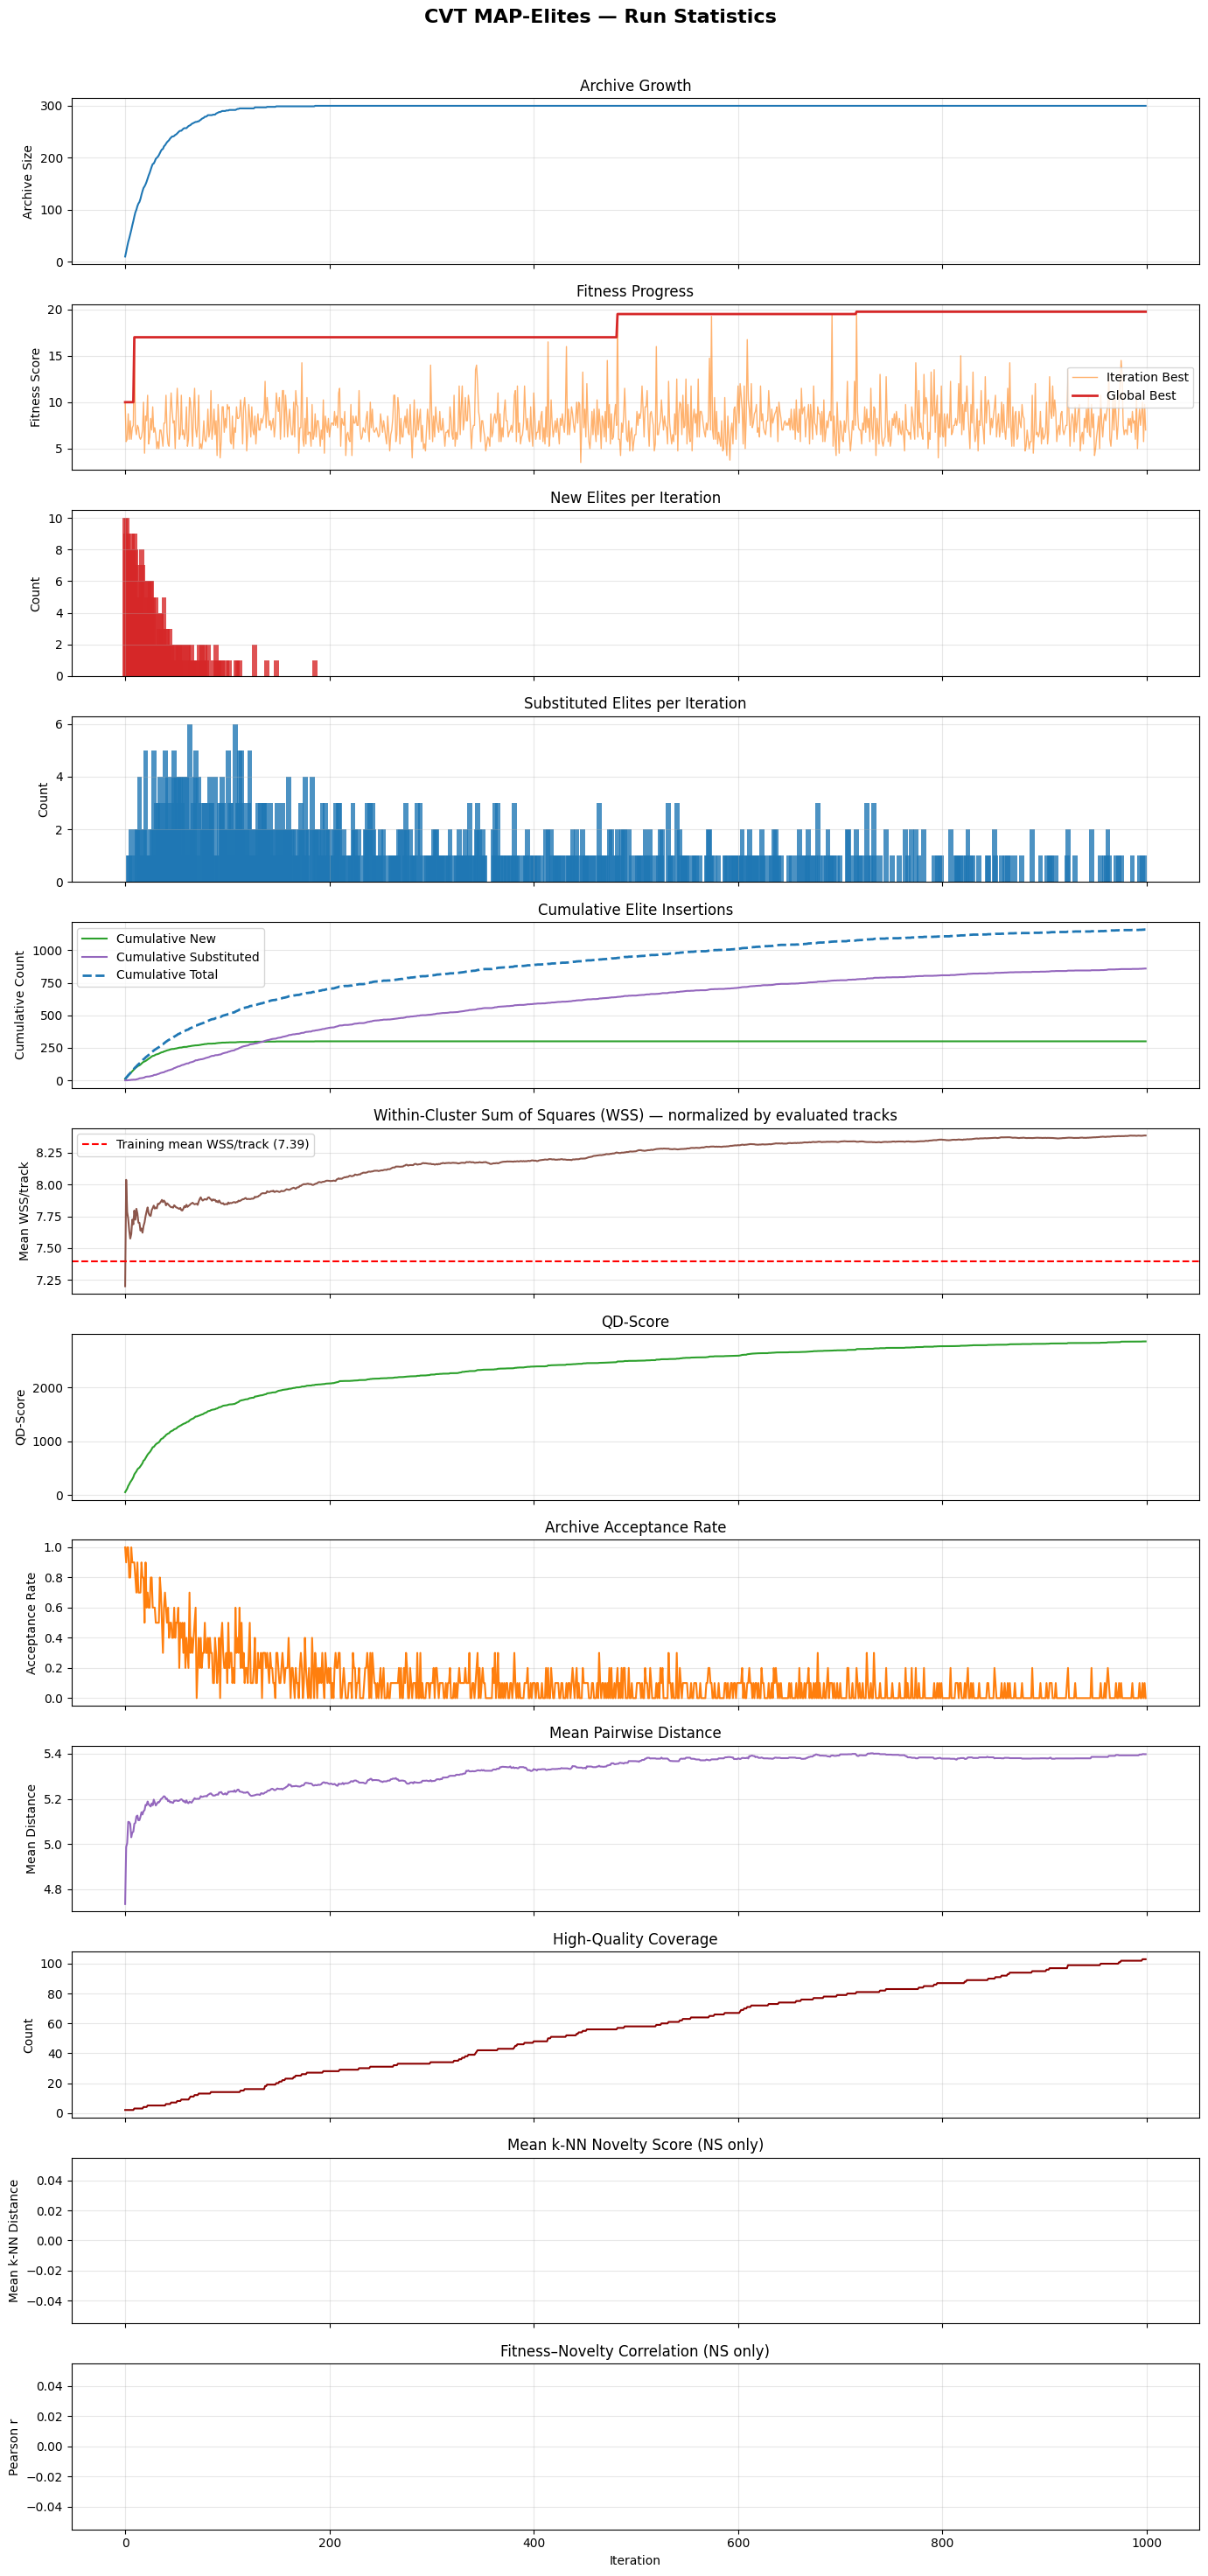

20:09:04 [INFO] Run summary | avg_new_per_iter=0.30 avg_sub_per_iter=0.86 final_archive_size=300 global_best_fitness=19.7500 title=CVT MAP-Elites total_iterations=1000 total_new_elites=300 total_substituted=860


In [9]:
runner.visualizer.plot_stats(title="CVT MAP-Elites", stats_dir=CVT_DIR)

In [10]:
runner.visualizer.export_elites(
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED,
)

20:09:04 [INFO] Elites exported | best_fitness=19.7500 best_id=716.6925495883561 count=300 file_kb=3294.2 path=data/cvt/elites.json worst_fitness=5.0000
